# 05 · CNN: 같은 작은 계산을 이미지 전체에 쓰기

**질문:** MLP는 픽셀마다 다른 가중치를 둡니다. 이미지의 어느 위치에 있든 같은 모양을 찾으려면 수식이 어떻게 바뀔까요?

이 노트북은 지역 연결 → 가중치 공유 → convolution → pooling → 역전파 → 작은 숫자 이미지 분류를 한 흐름으로 만듭니다. 앞의 00–04에서 배운 행렬곱·chain rule·CE·Adam을 사용합니다. 새 커널에서 위부터 실행하면 됩니다. 데이터는 본문에서 만드는 작은 숫자 도안이며 외부 다운로드는 없습니다.

학습 코드는 모두 본문에 있습니다. [그림 보조 파일](../../src/utils/architecture_plots.py)은 계산 결과만 그립니다. [전체 경로](../../docs/CURRICULUM.md) · [이전: optimizer](../00_기초/04_optimizers.ipynb)

두 번에 나누어 공부해도 됩니다. 먼저 1–4절의 패치·미분을 확인하고, 다음에 5–7절의 학습과 변형을 진행하세요.

In [1]:
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents)
                    if (p / "src/utils/plotting.py").is_file())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils.architecture_plots import plot_matrices, plot_curves, plot_images
setup_plots()
np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__, "· CNN 준비 완료")

NumPy 2.3.5 · CNN 준비 완료


## 1. 픽셀 하나를 만드는 수식부터

입력 $X$의 shape를 $(N,C,H,W)$, 필터 $K$를 $(F,C,k_h,k_w)$로 정합니다. $N$은 이미지 수, $C$는 입력 채널, $F$는 출력 채널입니다. 한 출력은 작은 입력 영역과 필터의 내적입니다.

$$Y_{n,f,i,j}=b_f+\sum_{c=0}^{C-1}\sum_{u=0}^{k_h-1}\sum_{v=0}^{k_w-1}
X^{pad}_{n,c,is+u,js+v}K_{f,c,u,v}.$$

$s$는 창을 한 번에 몇 픽셀 옮길지 정하는 stride, $p$는 사방에 더한 0의 두께입니다. $\lfloor a\rfloor$는 a 이하의 가장 큰 정수입니다. 끝에 창 전체가 들어가지 않는 위치는 제외하므로 내림을 씁니다.
$$H_o=\left\lfloor\frac{H+2p-k_h}{s}\right\rfloor+1,\quad
W_o=\left\lfloor\frac{W+2p-k_w}{s}\right\rfloor+1.$$

딥러닝에서 convolution이라고 부르는 위 연산은 필터를 뒤집지 않는 **cross-correlation**입니다. 여기서도 그 관례를 씁니다. 수학의 convolution과 부호·뒤집기 관례를 섞지 않습니다.

예를 들어 $\begin{bmatrix}1&2\\4&5\end{bmatrix}$와 $\begin{bmatrix}1&0\\0&-1\end{bmatrix}$의 내적은 $1-5=-4$입니다. 같은 필터를 오른쪽으로 옮겨도 파라미터는 새로 생기지 않습니다.

In [2]:
def conv_loops(X, K, b, stride=1, padding=0):
    N, C, H, W = X.shape
    F, Ck, kh, kw = K.shape
    assert C == Ck and stride >= 1 and padding >= 0
    Xp = np.pad(X, ((0, 0), (0, 0), (padding, padding), (padding, padding)))
    oh = (H + 2 * padding - kh) // stride + 1
    ow = (W + 2 * padding - kw) // stride + 1
    Y = np.zeros((N, F, oh, ow))
    for n in range(N):
        for f in range(F):
            for i in range(oh):
                for j in range(ow):
                    value = b[f]
                    for c in range(C):
                        for u in range(kh):
                            for v in range(kw):
                                value += Xp[n, c, i * stride + u, j * stride + v] * K[f, c, u, v]
                    Y[n, f, i, j] = value
    return Y

In [3]:
small_X = np.arange(1., 10.).reshape(1, 1, 3, 3)
small_K = np.array([[[[1., 0.], [0., -1.]]]])
small_Y = conv_loops(small_X, small_K, np.zeros(1))
np.testing.assert_allclose(small_Y, -4.)
print("출력 shape:", small_Y.shape, "· 첫 패치 내적:", small_Y[0, 0, 0, 0])

출력 shape: (1, 1, 2, 2) · 첫 패치 내적: -4.0


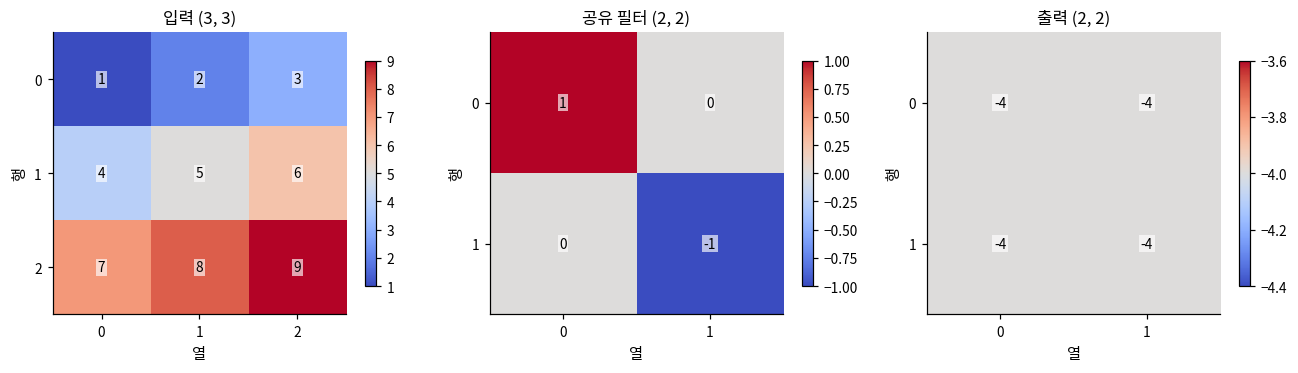

In [4]:
plot_matrices([small_X[0, 0], small_K[0, 0], small_Y[0, 0]],
              ["입력 (3, 3)", "공유 필터 (2, 2)", "출력 (2, 2)"])

네 위치의 출력이 모두 -4인 것은 이 입력의 대각선 차이가 같기 때문입니다. CNN이 언제나 같은 값을 내는 것은 아닙니다. 필터 값을 바꾼 뒤 다시 계산해 보세요.

같은 출력 크기의 완전 연결 층은 $(CHW+1)FH_oW_o$개 파라미터가 필요합니다. 지역 연결만 적용하면 $(Ck_hk_w+1)FH_oW_o$개, **공유까지 적용하면 $(Ck_hk_w+1)F$개**입니다. 공유는 서로 다른 위치가 같은 검출 규칙을 쓴다는 가정입니다.

In [5]:
C, H, W, F, kh, kw, oh, ow = 1, 8, 8, 6, 3, 3, 6, 6
print("완전 연결:", (C * H * W + 1) * F * oh * ow)
print("지역 연결만:", (C * kh * kw + 1) * F * oh * ow)
print("지역 연결 + 공유:", (C * kh * kw + 1) * F)

완전 연결: 14040
지역 연결만: 2160
지역 연결 + 공유: 60


## 2. 반복문을 패치 행렬과 행렬곱으로 옮기기

각 위치의 패치를 한 행에 펼쳐 $P\in\mathbb R^{(NH_oW_o)\times(Ck_hk_w)}$로 모읍니다. 필터를 행별로 펼친 $K_{flat}\in\mathbb R^{F\times(Ck_hk_w)}$에 대해
$$Y_{rows}=PK_{flat}^T+b.$$

새 수식이 생긴 것이 아니라, 1절의 같은 합을 행렬곱으로 묶은 것입니다. 패치 내부 축 순서 `(채널, 세로, 가로)`와 필터의 펼침 순서가 같아야 합니다. `transpose(0,3,1,2)`는 `(N,Ho,Wo,F)`를 `(N,F,Ho,Wo)`로 되돌립니다.

패치를 복사하는 구현이어서 메모리를 더 씁니다. 실제 라이브러리의 빠른 커널 구현까지 다루는 것은 이 실습의 범위 밖입니다.

In [6]:
def conv_forward(X, K, b, stride=1, padding=0):
    N, C, H, W = X.shape
    F, Ck, kh, kw = K.shape
    assert C == Ck and stride >= 1 and padding >= 0
    oh = (H + 2 * padding - kh) // stride + 1
    ow = (W + 2 * padding - kw) // stride + 1
    assert oh > 0 and ow > 0
    Xp = np.pad(X, ((0, 0), (0, 0), (padding, padding), (padding, padding)))
    patches = np.empty((N, oh, ow, C, kh, kw))
    for i in range(oh):
        for j in range(ow):
            patches[:, i, j] = Xp[:, :, i * stride:i * stride + kh, j * stride:j * stride + kw]
    P = patches.reshape(N * oh * ow, -1)
    rows = P @ K.reshape(F, -1).T + b
    Y = rows.reshape(N, oh, ow, F).transpose(0, 3, 1, 2)
    cache = (X.shape, K, P, stride, padding)
    return Y, cache

In [7]:
rng = np.random.default_rng(5)
check_X = rng.normal(size=(2, 2, 4, 5))
check_K = rng.normal(size=(3, 2, 2, 3))
check_b = rng.normal(size=3)
for stride, padding in [(1, 0), (2, 1)]:
    fast, _ = conv_forward(check_X, check_K, check_b, stride, padding)
    slow = conv_loops(check_X, check_K, check_b, stride, padding)
    np.testing.assert_allclose(fast, slow, atol=1e-12)
    print(f"stride={stride}, padding={padding}: {fast.shape}, 최대 오차={np.max(np.abs(fast-slow)):.2e}")

stride=1, padding=0: (2, 3, 3, 3), 최대 오차=1.78e-15
stride=2, padding=1: (2, 3, 3, 3), 최대 오차=8.88e-16


## 3. 공유한 파라미터로 돌아오는 기울기는 더합니다

$G=\partial L/\partial Y_{rows}$라 두면 01의 affine backward가 그대로 나옵니다.
$$dK_{flat}=G^TP,\qquad db=\sum_{rows}G,\qquad dP=GK_{flat}.$$

한 입력 픽셀이 여러 패치에 들어갔으면 그 픽셀로 돌아오는 $dP$도 모두 합해야 합니다. 그래서 아래 코드는 `dXp[..., 영역] += 패치 기울기`입니다. `=`로 쓰면 뒤에 온 패치가 앞의 기여를 지웁니다.

검사에서는 임의의 상류 배열 $G$를 정하고 스칼라 $L=\sum Y\odot G$를 만듭니다. 이때 $dL/dY=G$이므로 backward가 반환한 dX·dK·db를 같은 스칼라의 중심차분과 비교할 수 있습니다.

공유 위치 수로 다시 평균내지 않습니다. 손실에서 배치 평균을 했다면 그 계수는 이미 상류 기울기 $G$에 있습니다.

In [8]:
def conv_backward(dY, cache):
    shape, K, P, stride, padding = cache
    N, C, H, W = shape
    F, _, kh, kw = K.shape
    _, _, oh, ow = dY.shape
    G = dY.transpose(0, 2, 3, 1).reshape(N * oh * ow, F)
    dK = (G.T @ P).reshape(K.shape)
    db = G.sum(axis=0)
    dpatches = (G @ K.reshape(F, -1)).reshape(N, oh, ow, C, kh, kw)
    dXp = np.zeros((N, C, H + 2 * padding, W + 2 * padding))
    for i in range(oh):
        for j in range(ow):
            dXp[:, :, i * stride:i * stride + kh, j * stride:j * stride + kw] += dpatches[:, i, j]
    dX = dXp[:, :, padding:padding + H, padding:padding + W]
    return dX, dK, db


def check_conv_backward(candidate):
    rng = np.random.default_rng(51)
    errors = {}
    for stride, padding in [(1, 0), (2, 1)]:
        X = rng.normal(size=(1, 2, 4, 5))
        K = rng.normal(size=(2, 2, 2, 3))
        b = rng.normal(size=2)
        Y, cache = conv_forward(X, K, b, stride, padding)
        G = rng.normal(size=Y.shape)
        dX, dK, db = candidate(G, cache)
        analytic = (dX, dK, db)
        for value, grad in zip((X, K, b), analytic):
            assert np.shape(grad) == value.shape, (np.shape(grad), value.shape)
        scalar = lambda: float(np.sum(conv_forward(X, K, b, stride, padding)[0] * G))
        for name, array, grad in zip(["X", "K", "b"], [X, K, b], analytic):
            numeric = numerical_gradient(scalar, array)
            error = rel_error(grad, numeric)
            assert np.isfinite(error) and error < 2e-6, (name, error)
            errors[f"s{stride}p{padding}/{name}"] = error
    return errors

In [9]:
conv_errors = check_conv_backward(conv_backward)
print("convolution 전체 미분 최대 상대오차:", max(conv_errors.values()))
ones_X = np.ones((1, 1, 3, 3))
ones_K = np.ones((1, 1, 2, 2))
ones_Y, ones_cache = conv_forward(ones_X, ones_K, np.zeros(1))
coverage, _, _ = conv_backward(np.ones_like(ones_Y), ones_cache)
np.testing.assert_allclose(coverage[0, 0], [[1, 2, 1], [2, 4, 2], [1, 2, 1]])

convolution 전체 미분 최대 상대오차: 5.484114245342819e-10


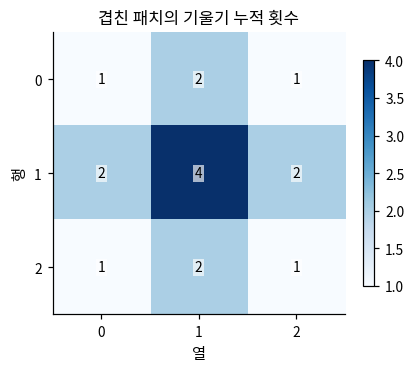

In [10]:
plot_matrices([coverage[0, 0]], ["겹친 패치의 기울기 누적 횟수"], cmap="Blues")

중앙 픽셀은 네 패치에 등장하여 네 경로의 기울기를 받습니다. 이 그림의 숫자는 helper가 만든 설명용 값이 아니라 실제 backward의 출력입니다.

## 4. Pooling은 공간 크기를 줄이는 다른 연산입니다

2×2 **평균 pooling**은 네 값을 더해 4로 나누므로 각 입력 미분도 $dY/4$입니다. **최대 pooling**은 최대값을 만든 입력 하나로 기울기를 보냅니다. 동률에서는 미분이 유일하지 않으며, 아래 구현은 펼친 순서의 첫 최대 위치를 택합니다. 수치미분 검사는 동률을 피합니다.

여기서는 창 크기=stride=2, padding=0이고 입력 높이·너비가 짝수인 경우만 구현합니다. 일반 stride와 겹치는 pooling은 마지막 확장 문제입니다. `reshape(N,C,H//2,2,W//2,2)`에서 축 3·5가 각 창의 내부 위치입니다.

In [11]:
def pool_forward(X, mode="mean"):
    N, C, H, W = X.shape
    assert H % 2 == W % 2 == 0 and mode in ("mean", "max")
    windows = X.reshape(N, C, H // 2, 2, W // 2, 2).transpose(0, 1, 2, 4, 3, 5)
    flat = windows.reshape(N, C, H // 2, W // 2, 4)
    if mode == "mean":
        Y, indices = flat.mean(axis=-1), None
    else:
        indices = flat.argmax(axis=-1)
        Y = flat.max(axis=-1)
    return Y, (X.shape, mode, indices)


def pool_backward(dY, cache):
    shape, mode, indices = cache
    N, C, H, W = shape
    if mode == "mean":
        dflat = np.repeat(dY[..., None] / 4, 4, axis=-1)
    else:
        mask = np.arange(4) == indices[..., None]
        dflat = dY[..., None] * mask
    return dflat.reshape(N, C, H // 2, W // 2, 2, 2).transpose(0, 1, 2, 4, 3, 5).reshape(shape)

In [12]:
pool_X = rng.normal(size=(1, 2, 4, 4))
for mode in ["mean", "max"]:
    Yp, cp = pool_forward(pool_X, mode)
    upstream = rng.normal(size=Yp.shape)
    numeric = numerical_gradient(lambda: float(np.sum(pool_forward(pool_X, mode)[0] * upstream)), pool_X)
    error = rel_error(pool_backward(upstream, cp), numeric)
    assert error < 2e-6
    print(mode, "backward 상대오차", error)
hand_pool = np.array([[[[1., 2.], [3., 4.]]]])
np.testing.assert_allclose(pool_forward(hand_pool)[0], 2.5)
max_Y, max_cache = pool_forward(hand_pool, "max")
np.testing.assert_allclose(pool_backward(np.ones_like(max_Y), max_cache), [[[[0, 0], [0, 1]]]])

mean backward 상대오차 1.8890476578625065e-10
max backward 상대오차 4.15233628616863e-10


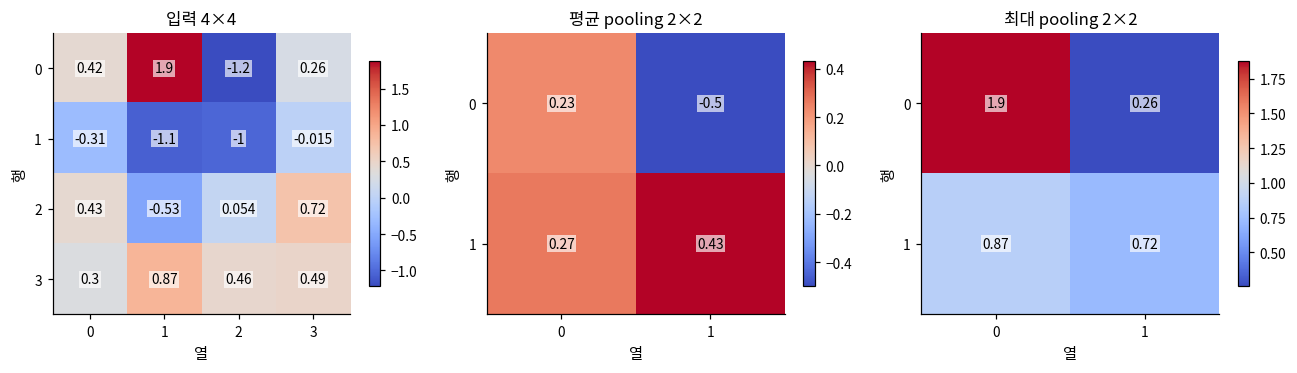

In [13]:
plot_matrices([pool_X[0, 0], pool_forward(pool_X)[0][0, 0], pool_forward(pool_X, "max")[0][0, 0]],
              ["입력 4×4", "평균 pooling 2×2", "최대 pooling 2×2"])

pooling은 정보를 버립니다. 작은 이동에 덜 민감해질 수 있지만, **모든 이동에 대한 완전한 불변성을 보장하지 않습니다.** stride·경계·뒤의 flatten 층에 따라 이동 효과가 달라집니다.

## 5. 작은 완성 모델: 숫자 도안 → convolution → 분류

입력은 8×8에 그린 0–9 도안입니다. 원본 모양을 직접 적고 위치와 잡음을 무작위로 바꿉니다. 학습 500장, 검증 200장은 별도 난수로 생성합니다. 검증 집합은 가중치 갱신에 쓰지 않습니다. 두 집합이 같은 10개 도안 생성 규칙을 공유하므로 결과는 **그 규칙 안의 새 위치·잡음에 대한 성능**입니다. 실제 손글씨나 MNIST 성능으로 읽지 마세요.

모델의 shape 흐름:
`(N,1,8,8) → conv 3×3 → (N,6,6,6) → ReLU → mean pool → (N,6,3,3) → flatten 54 → logits 10`.

In [14]:
def make_digits(n, seed):
    patterns = ["111/101/101/101/111", "010/110/010/010/111", "111/001/111/100/111",
                "111/001/111/001/111", "101/101/111/001/001", "111/100/111/001/111",
                "111/100/111/101/111", "111/001/001/010/010", "111/101/111/101/111",
                "111/101/111/001/111"]
    templates = np.array([[[int(v) for v in row] for row in p.split("/")] for p in patterns])
    rng = np.random.default_rng(seed)
    y = np.arange(n) % 10
    rng.shuffle(y)
    X = np.zeros((n, 1, 8, 8))
    for i, label in enumerate(y):
        top, left = rng.integers(0, 4), rng.integers(0, 6)
        X[i, 0, top:top + 5, left:left + 3] = templates[label]
    X = np.clip(X + rng.normal(0, 0.06, X.shape), 0, 1)
    return X, y


def ce_loss(logits, y):
    shifted = logits - logits.max(axis=1, keepdims=True)
    logp = shifted - np.log(np.exp(shifted).sum(axis=1, keepdims=True))
    loss = -logp[np.arange(len(y)), y].mean()
    dlogits = np.exp(logp)
    dlogits[np.arange(len(y)), y] -= 1
    return loss, dlogits / len(y)


def cnn_forward(X, p):
    Z, conv_cache = conv_forward(X, p["K"], p["c"])
    A = np.maximum(Z, 0)
    pooled, pool_cache = pool_forward(A)
    flat = pooled.reshape(len(X), -1)
    logits = flat @ p["W"] + p["b"]
    return logits, (Z, conv_cache, pool_cache, flat, pooled.shape)


def cnn_backward(dlogits, cache, p):
    Z, conv_cache, pool_cache, flat, pooled_shape = cache
    dW, db = flat.T @ dlogits, dlogits.sum(axis=0)
    dpool = (dlogits @ p["W"].T).reshape(pooled_shape)
    dZ = pool_backward(dpool, pool_cache) * (Z > 0)
    dX, dK, dc = conv_backward(dZ, conv_cache)
    return dX, {"K": dK, "c": dc, "W": dW, "b": db}

In [15]:
X_train, y_train = make_digits(500, 501)
X_valid, y_valid = make_digits(200, 502)
print("학습:", X_train.shape, "검증:", X_valid.shape)

학습: (500, 1, 8, 8) 검증: (200, 1, 8, 8)


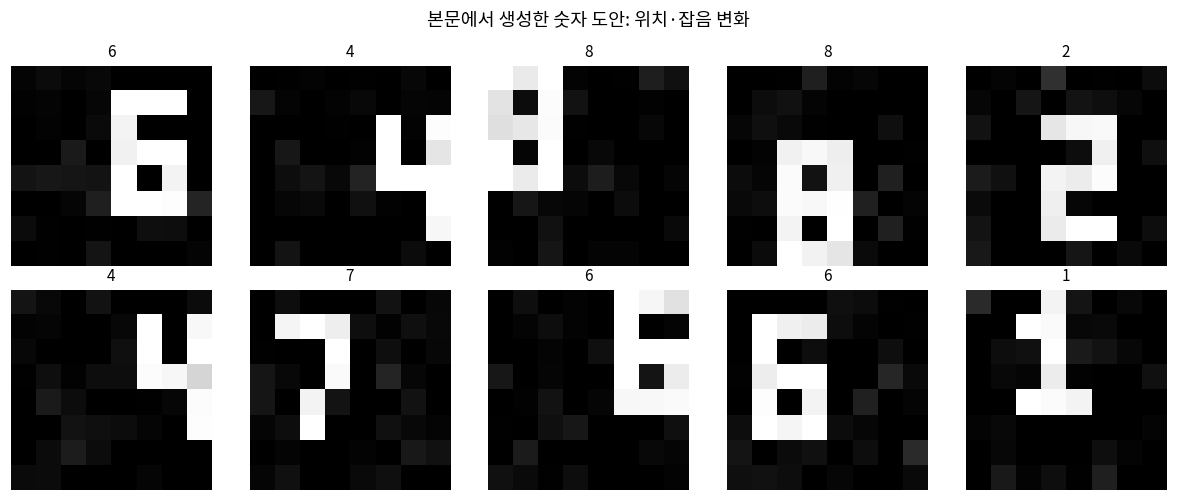

In [16]:
plot_images(X_train[:10, 0], y_train[:10], title="본문에서 생성한 숫자 도안: 위치·잡음 변화")

CE와 Adam은 02·04의 계산을 여기에도 적습니다. `p`와 `grads`는 같은 이름을 가진 배열의 사전입니다. `state`에는 파라미터별 1차·2차 이동평균을 저장합니다. 모든 기울기를 **같은 갱신 전 파라미터**에서 구한 다음 함께 갱신합니다.

먼저 모델 전체의 파라미터와 입력 미분도 검사합니다. ReLU는 0에서 꺾이므로 이 검사에서는 꺾임에서 떨어진 입력을 사용합니다. 학습 성능이 올라가는 것만으로 미분 구현이 맞다고 판단하지 않습니다.

In [17]:
def adam_update(p, grads, state, step, lr=0.02):
    for key in p:
        m, v = state[key]
        m = 0.9 * m + 0.1 * grads[key]
        v = 0.999 * v + 0.001 * grads[key] ** 2
        p[key] -= lr * (m / (1 - 0.9 ** step)) / (np.sqrt(v / (1 - 0.999 ** step)) + 1e-8)
        state[key] = (m, v)


def init_cnn(seed=503):
    rng = np.random.default_rng(seed)
    return {"K": rng.normal(size=(6, 1, 3, 3)) * np.sqrt(2 / 9), "c": np.zeros(6),
            "W": rng.normal(size=(54, 10)) * np.sqrt(1 / 54), "b": np.zeros(10)}

In [18]:
probe_X = rng.normal(size=(1, 1, 8, 8))
probe_p = init_cnn(504)
probe_logits, probe_cache = cnn_forward(probe_X, probe_p)
probe_G = rng.normal(size=probe_logits.shape)
probe_dX, probe_grads = cnn_backward(probe_G, probe_cache, probe_p)
scalar = lambda: float(np.sum(cnn_forward(probe_X, probe_p)[0] * probe_G))
cnn_errors = {key: rel_error(probe_grads[key], numerical_gradient(scalar, value)) for key, value in probe_p.items()}
cnn_errors["X"] = rel_error(probe_dX, numerical_gradient(scalar, probe_X))
assert max(cnn_errors.values()) < 2e-6
print("CNN 합성 전체 미분 최대 상대오차:", max(cnn_errors.values()))

CNN 합성 전체 미분 최대 상대오차: 8.04833810323961e-10


In [19]:
p = init_cnn()
state = {key: (np.zeros_like(value), np.zeros_like(value)) for key, value in p.items()}
rng_train = np.random.default_rng(505)
history = {"step": [], "train": [], "valid": []}
for step in range(601):
    if step % 50 == 0:
        train_logits, _ = cnn_forward(X_train, p)
        valid_logits, _ = cnn_forward(X_valid, p)
        history["step"].append(step)
        history["train"].append(ce_loss(train_logits, y_train)[0])
        history["valid"].append(ce_loss(valid_logits, y_valid)[0])
    if step == 600:
        break
    batch = rng_train.choice(len(X_train), 50, replace=False)
    logits, cache = cnn_forward(X_train[batch], p)
    loss, dlogits = ce_loss(logits, y_train[batch])
    _, grads = cnn_backward(dlogits, cache, p)
    adam_update(p, grads, state, step + 1)
valid_predictions = valid_logits.argmax(axis=1)
valid_accuracy = np.mean(valid_predictions == y_valid)
print(f"학습 CE {history['train'][0]:.6f} → {history['train'][-1]:.6f}")
print(f"검증 CE {history['valid'][-1]:.6f} · 정확도 {valid_accuracy:.1%} (n={len(y_valid)})")
assert history["train"][-1] < history["train"][0] * 0.4
assert valid_accuracy > 0.8

학습 CE 2.345114 → 0.087676
검증 CE 0.229319 · 정확도 93.5% (n=200)


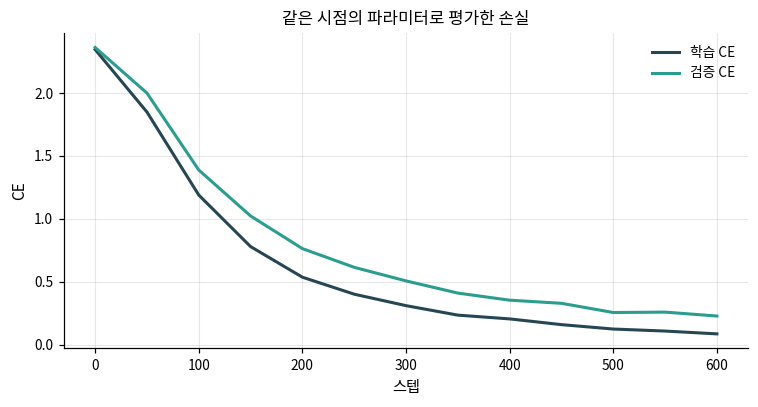

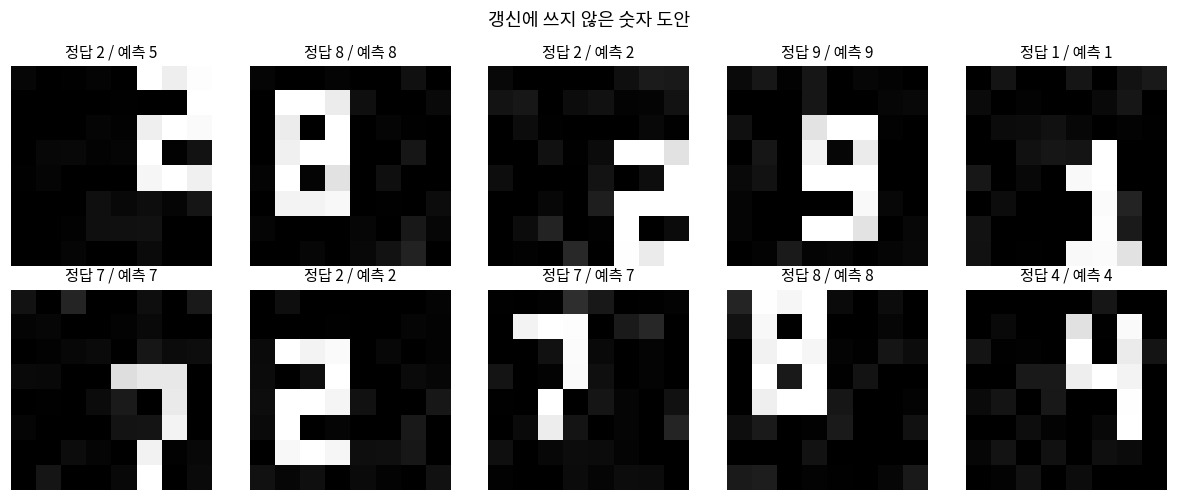

In [20]:
plot_curves(history["step"], {"학습 CE": history["train"], "검증 CE": history["valid"]},
            title="같은 시점의 파라미터로 평가한 손실", ylabel="CE")
plot_images(X_valid[:10, 0], [f"정답 {a} / 예측 {b}" for a, b in zip(y_valid[:10], valid_predictions[:10])],
            title="갱신에 쓰지 않은 숫자 도안")

## 6. 공유는 이동에 대한 어떤 성질을 줍니까?

stride=1인 convolution에 주기적 경계(`np.roll`)를 함께 적용하면 입력 이동과 출력 이동이 대응합니다. 아래에서는 경계 영향을 없애기 위해 `padding='wrap'`에 해당하는 입력을 본문에서 만들고 valid convolution을 적용합니다. 일반적인 **0 padding 경계에서는 같은 등식이 그대로 성립하지 않습니다.**

이는 출력도 같이 움직이는 **equivariance**입니다. 출력 자체가 같아지는 **invariance**와 구분합니다. 뒤에 flatten+위치별 가중치를 붙인 이 분류기 전체에 이동 불변성을 주장할 수는 없습니다.

In [21]:
def periodic_conv(X, K):
    wrapped = np.pad(X, ((0, 0), (0, 0), (1, 1), (1, 1)), mode="wrap")
    return conv_forward(wrapped, K, np.zeros(len(K)))[0]

shift_X = rng.normal(size=(1, 1, 5, 5))
shift_K = rng.normal(size=(2, 1, 3, 3))
base = periodic_conv(shift_X, shift_K)
moved = periodic_conv(np.roll(shift_X, 1, axis=3), shift_K)
np.testing.assert_allclose(moved, np.roll(base, 1, axis=3), atol=1e-12)
print("주기적 경계 + stride 1의 이동 대응 검산 통과")

주기적 경계 + stride 1의 이동 대응 검산 통과


## 7. 직접 바꾸기: 읽은 함수를 자신의 함수로 만들기

Jupyter에서 `Esc`, `B`로 아래에 코드 셀을 만든 뒤, 예를 들어 `def my_conv_backward(dY, cache): ...`를 작성하세요. 완성 함수는 위에 있으므로 처음에는 참고해도 됩니다. `check_conv_backward(my_conv_backward)`로 **자신의 함수**를 전달해야 합니다. 인자 없이 원본만 재검사하는 것은 풀이 확인이 아닙니다.

1. **누적:** convolution backward를 직접 쓰고, `+=`가 필요한 곳을 설명하세요. stride=2, padding=1의 검사까지 통과시키세요.
2. **평균 pooling:** 입력 크기가 `(2,3,4,6)`이어도 동작하도록 직접 구현하고 아래 검사기에 넣으세요. 최대 pooling의 첫 최대 위치 관례도 비교하세요.
3. **실험:** 필터 수를 6→3으로 바꾸면 head의 입력 차원은 얼마입니까? 초기화·reshape·파라미터 수를 먼저 적고, 같은 학습/검증 데이터와 600 스텝으로 다시 실행하세요. 성능 변화가 한 번의 seed 때문일 가능성도 남겨 두세요.

검사기의 역할을 확인하기 위해 일부러 잘못된 풀이도 실행합니다. 아래의 실패는 의도한 검사 결과이며, 노트북 실행 오류가 아닙니다.

In [22]:
def check_mean_pool_backward(candidate):
    rng = np.random.default_rng(57)
    X = rng.normal(size=(2, 3, 4, 6))
    Y, cache = pool_forward(X, "mean")
    G = rng.normal(size=Y.shape)
    got = candidate(G, cache)
    numeric = numerical_gradient(lambda: float(np.sum(pool_forward(X)[0] * G)), X)
    np.testing.assert_allclose(got, numeric, atol=1e-8, rtol=1e-6)
    return "평균 pooling 변형 통과"


def wrong_average(dY, cache):
    return pool_backward(dY, cache) * 4  # /4를 빠뜨린 풀이

In [23]:
print(check_mean_pool_backward(pool_backward))
try:
    check_mean_pool_backward(wrong_average)
except AssertionError:
    print("의도적 오답 검출: 평균의 /4 누락")
else:
    raise AssertionError("검사기가 오답을 놓쳤습니다")

평균 pooling 변형 통과
의도적 오답 검출: 평균의 /4 누락


### 준비도 확인

- **설명:** convolution에서 무엇이 지역적이고 무엇이 공유되는지 설명할 수 있습니까?
- **수식:** padding·stride를 포함해 출력 shape와 한 출력의 합을 쓸 수 있습니까?
- **구현:** 패치 펼침의 축 순서, dK의 위치 합, dX의 겹침 누적을 직접 쓸 수 있습니까?
- **변형:** 채널·필터·stride를 바꿔도 수치미분을 통과시키고, equivariance와 invariance를 구분할 수 있습니까?

[LeCun 등, 1998](https://bottou.org/papers/lecun-98h)은 지역 수용 영역과 가중치 공유를 사용한 문서 인식 CNN의 원전입니다. 이 노트북의 작은 도안 데이터와 모델은 설명을 위해 새로 구성한 예제이며 LeNet의 재현 실험은 아닙니다.

다음은 [06 RNN](06_rnn.ipynb)입니다. 이미지의 **위치**에 공유한 가중치를 시간의 **단계**에 공유해 봅니다.